In [1]:
import torch
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\26911\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\26911\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

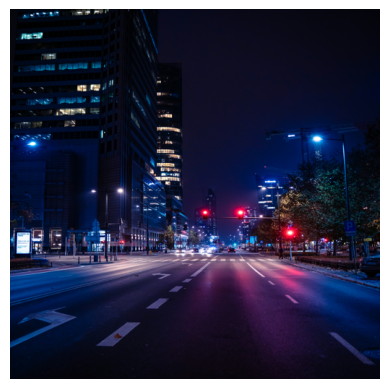

In [3]:
image_path = "C:/Users/26911/Desktop/diffusion_style_project/data/content/content_001.jpg"

init_image = Image.open(image_path).convert("RGB")
init_image = init_image.resize((512, 512))

plt.imshow(init_image)
plt.axis("off")

  0%|          | 0/37 [00:00<?, ?it/s]

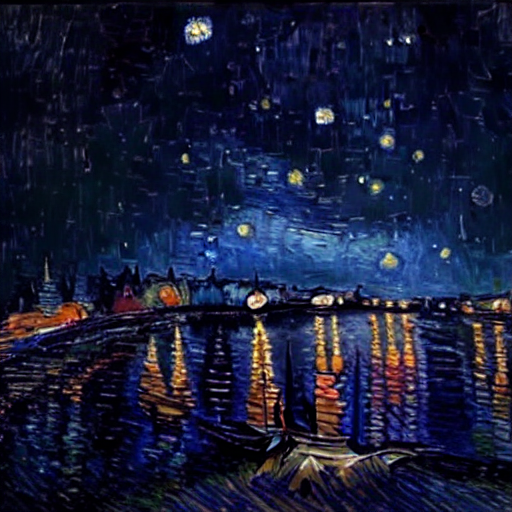

In [4]:
prompt = "a painting in the style of Vincent van Gogh"

result = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=7.5
)

stylized_image = result.images[0]

stylized_image

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

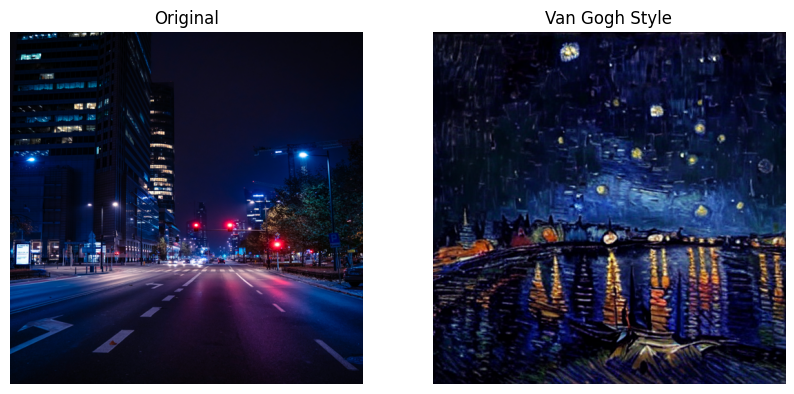

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(init_image)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(stylized_image)
ax[1].set_title("Van Gogh Style")
ax[1].axis("off")

  0%|          | 0/37 [00:00<?, ?it/s]

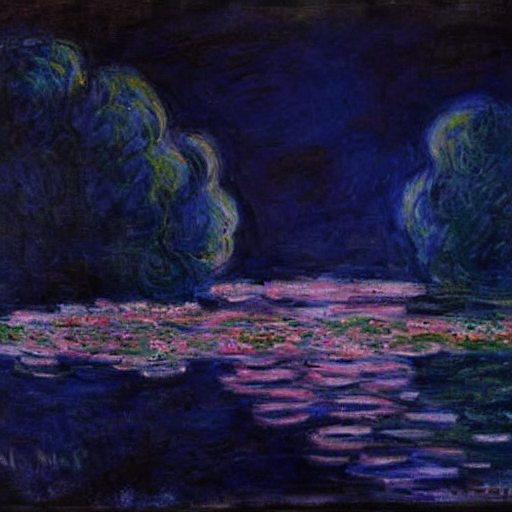

In [6]:
prompt = "a painting in the style of Claude Monet"

result = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=7.5
)

monet_image = result.images[0]

monet_image

  0%|          | 0/37 [00:00<?, ?it/s]

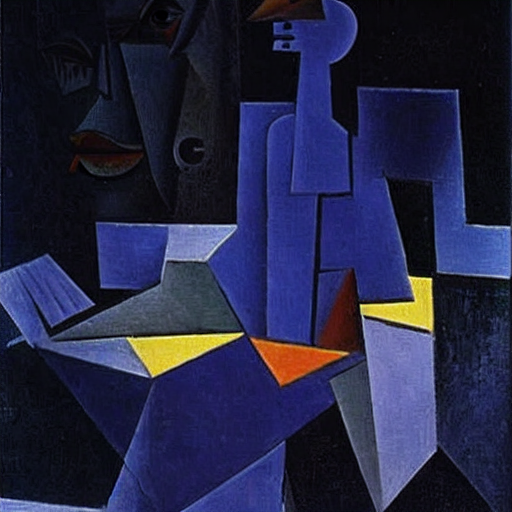

In [7]:
prompt = "cubism painting style, by Pablo Picasso"

result = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=7.5
)

cubism_image = result.images[0]

cubism_image

In [8]:
stylized_image.save("C:/Users/26911/Desktop/diffusion_style_project/results/vangogh_result.png")
monet_image.save("C:/Users/26911/Desktop/diffusion_style_project/results/monet_result.png")
cubism_image.save("C:/Users/26911/Desktop/diffusion_style_project/results/cubism_result.png")